In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [9]:
# Download data real-time đến ngày hiện tại
df = yf.download('BTC-USD', start='2014-09-17', end='2025-07-22')
df.to_csv('../Data/BTC-USD.csv')

# Đặt tên cột thủ công
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
df['Date'] = df.index
df.set_index('Date', inplace=True)

# Kiểm tra DataFrame
print(df.head())
print(df.tail())
df.info()

C:\Users\VincentPham\AppData\Local\Temp\ipykernel_3852\1737933298.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2014-09-17', end='2025-07-22')
[*********************100%***********************]  1 of 1 completed


                  Open        High         Low       Close    Volume
Date                                                                
2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100
                     Open           High            Low          Close  \
Date                                                                     
2025-07-16  118738.507812  120065.515625  117064.820312  117777.187500   
2025-07-17  119289.843750  120999.609375  117508.218750  118738.507812   
2025-07-18  118003.226562  120851.914062  116925.984375  119284.109375   
2025-07-19  117939.976562  118541.398438  117388.414062  117998.125000   
2025-07-20  117300.789062  118865.031250  116550.132812  117944.109375   

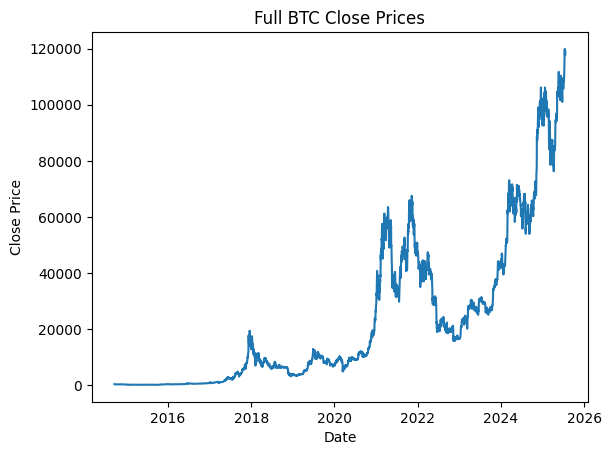

In [10]:
# Plot full dataset
plt.plot(df.index, df['Close'])
plt.title('Full BTC Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [11]:
# Tạo thư mục lưu kết quả và model
output_dir = '../'
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

output_dir_result = os.path.join(output_dir, 'Result/')
if not os.path.exists(output_dir_result):
    os.makedirs(output_dir_result, exist_ok=True)

output_dir_models = os.path.join(output_dir, 'Models/')
if not os.path.exists(output_dir_models):
    os.makedirs(output_dir_models, exist_ok=True)

In [12]:
# Kiểm tra stationary với ADF test
result = adfuller(df['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: 0.5792915658296922
p-value: 0.9870939225271624
Critical Values: {'1%': -3.432015880491298, '5%': -2.862276094831294, '10%': -2.5671618317520877}


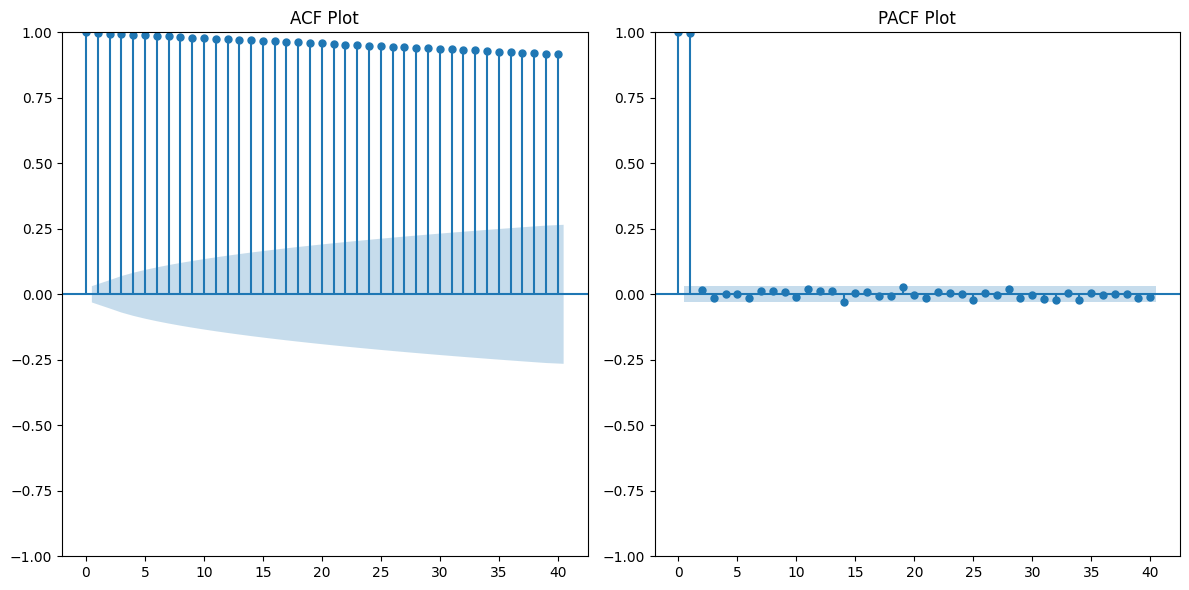

In [13]:
# Plot ACF và PACF để chọn order
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['Close'], lags=40, ax=plt.gca())
plt.title('ACF Plot')
plt.subplot(122)
plot_pacf(df['Close'], lags=40, ax=plt.gca())
plt.title('PACF Plot')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_result, 'arima_acf_pacf.png'), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Log transform data
df['Close_Log'] = np.log(df['Close'])

In [15]:
# Split train/test với 80% train
to_row = int(len(df) * 0.8)
training_data_log = df[0:to_row]['Close_Log']
testing_data_log = df[to_row:]['Close_Log']

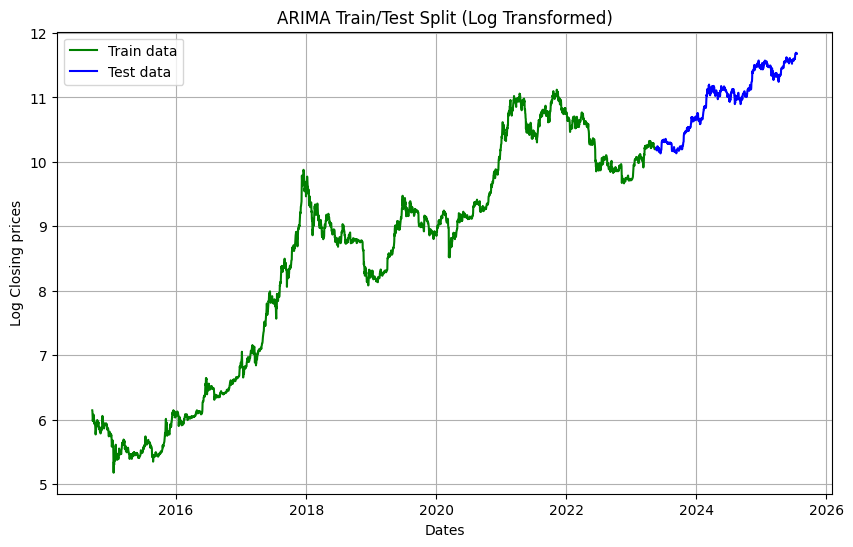

In [16]:
# Plot train/test split (với log data để xem)
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Log Closing prices')
plt.plot(training_data_log, 'green', label='Train data')
plt.plot(testing_data_log, 'blue', label='Test data')
plt.legend()
plt.title('ARIMA Train/Test Split (Log Transformed)')
plt.savefig(os.path.join(output_dir_result, 'arima_train_test_split_log.png'), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Rolling forecast với SARIMA trên log data (order từ ADF/ACF: giả sử (2,1,0), seasonal (1,1,1,7))
model_predictions_log = []
n_test_obser = len(testing_data_log)

for i in range(n_test_obser):
    model = SARIMAX(training_data_log, order=(4,1,0), seasonal_order=(1,1,1,7))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat_log = output.iloc[0]
    model_predictions_log.append(yhat_log)
    actual_test_value_log = testing_data_log.iloc[i]
    training_data_log = pd.concat([training_data_log, pd.Series([actual_test_value_log], index=[testing_data_log.index[i]])])
    print(output)

# Chuyển ngược log predictions về mức giá thực
model_predictions = np.exp(model_predictions_log)

c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2023-05-21    10.201029
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2023-05-22    10.207702
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

2025-07-18    11.683114
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2025-07-19    11.690397
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2025-07-20    11.680187
Freq: D, dtype: float64


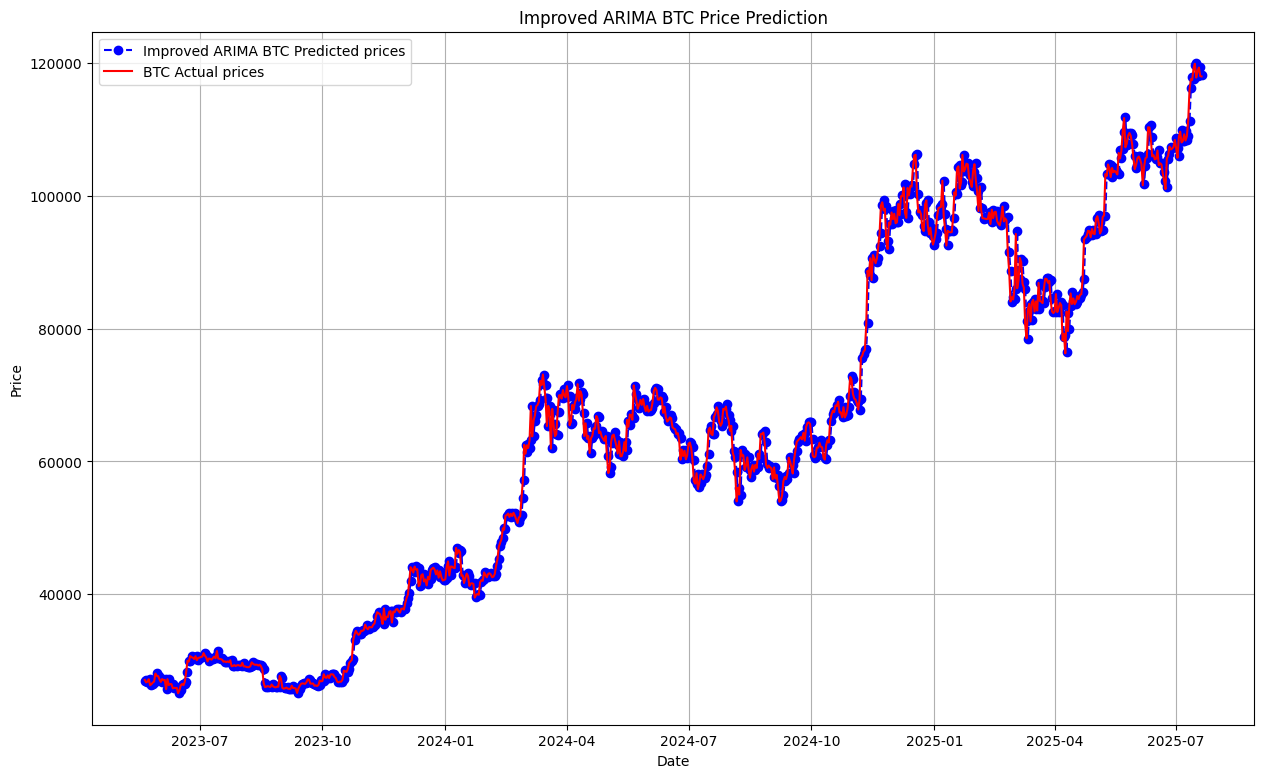

In [18]:
# Vẽ plot prediction
plt.figure(figsize=(15,9))
plt.grid()

data_range = df[to_row:].index

plt.plot(data_range, model_predictions, color='blue', marker='o', linestyle='dashed', label='Improved ARIMA BTC Predicted prices')
plt.plot(data_range, df[to_row:]['Close'], color='red', label='BTC Actual prices')
plt.title('Improved ARIMA BTC Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.savefig(os.path.join(output_dir_result, 'improved_arima_btc_price_prediction.png'), dpi=300, bbox_inches='tight')
plt.show()

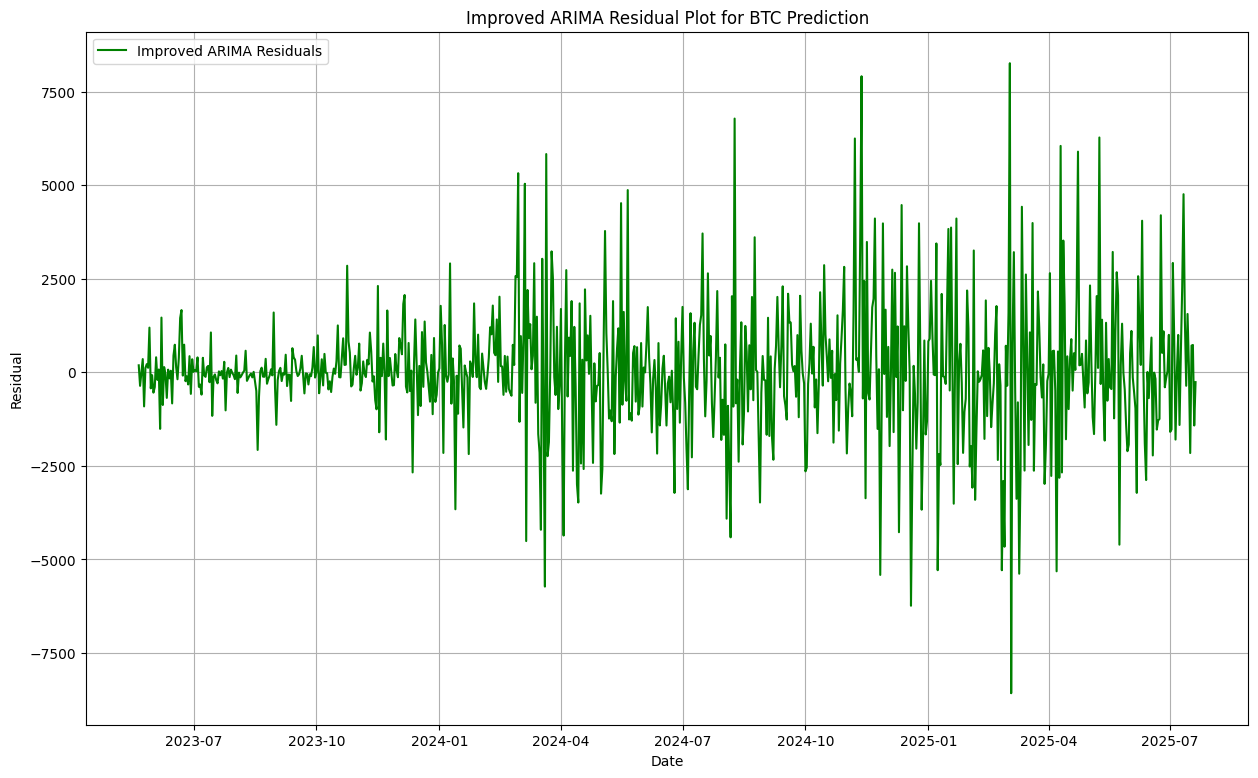

In [19]:
# Tính residuals
residuals = df[to_row:]['Close'] - model_predictions

# Vẽ residual plot
plt.figure(figsize=(15,9))
plt.grid()

plt.plot(data_range, residuals, color='green', label='Improved ARIMA Residuals')
plt.title('Improved ARIMA Residual Plot for BTC Prediction')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()

plt.savefig(os.path.join(output_dir_result, 'improved_arima_btc_residual_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Tính metrics
mape = np.mean(np.abs(df[to_row:]['Close'] - model_predictions) / np.abs(df[to_row:]['Close']))
mae = mean_absolute_error(df[to_row:]['Close'], model_predictions)
mse = mean_squared_error(df[to_row:]['Close'], model_predictions)
rmse = math.sqrt(mse)

# Tạo DataFrame so sánh
results_df = pd.DataFrame({
    'Date': data_range,
    'Predicted': model_predictions,
    'Actual': df[to_row:]['Close']
})

# Thêm metrics vào DataFrame
results_df['MAPE'] = mape
results_df['MAE'] = mae
results_df['MSE'] = mse
results_df['RMSE'] = rmse

# Save CSV vào output_dir_result
results_df.to_csv(os.path.join(output_dir_result, 'improved_arima_btc_predictions_and_metrics.csv'), index=False)

# In metrics để kiểm tra
print('Improved ARIMA Mean Absolute Percentage Error:', mape)
print('Improved ARIMA Mean Squared Error:', mse)
print('Improved ARIMA Root Mean Squared Error:', rmse)
print('Improved ARIMA Mean Absolute Error:', mae)

Improved ARIMA Mean Absolute Percentage Error: 0.017371818017451683
Improved ARIMA Mean Squared Error: 2950075.5502993264
Improved ARIMA Root Mean Squared Error: 1717.5783971333963
Improved ARIMA Mean Absolute Error: 1136.4710955671624


In [21]:
# Save model vào output_dir_models (lưu model_fit cuối cùng từ loop)
joblib.dump(model_fit, os.path.join(output_dir_models, 'improved_arima_btc_model.pkl'))
print("Improved ARIMA model saved successfully.")

Improved ARIMA model saved successfully.
